# COMP 352 – Final Project: Footballer Market Evaluation  
**Goal:** Predict a footballer’s **market value next year** using **only historical information** (no future leakage).  

**Authors:** Zevin Attisha, Christian Vaikona, Santiago Guerrero, Santiago Pedetti   

**Dataset source:** https://www.kaggle.com/datasets/davidcariboo/player-scores  

---

## Table of Contents
1. Environment Setup  
2. Data Importing and Pre-processing  
3. Data Analysis and Visualization  
4. Data Analytics (Modeling)  
5. Summary / Conclusions  


## 1. Data Importing and Pre-processing (100 Points)
- Import dataset and describe characteristics such as dimensions, data types, file types, and import methods used
- Clean, wrangle, and handle missing data, duplicate data, etc.
- Encode any categorical variables
- Perform feature engineering on the dataset
- Transform data appropriately using techniques such as aggregation, normalization, and feature construction
- Reduce redundant data and perform need based discretization

We load two datasets:
- `player_valuations.csv`: multiple valuation records per player over time
- `players.csv`: one record per player with demographic and categorical info

We then clean data, engineer historical features, and build a **time-based target**: next year's market value.

## Environment Setup
This notebook uses common Python data science libraries (pandas, numpy, matplotlib, scikit-learn).

In [28]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, TimeSeriesSplit, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression, ElasticNet
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score


pd.set_option("display.max_columns", None)
np.set_printoptions(suppress=True)

In [29]:
PATH_PLAYER_VALUATIONS = "data/raw/player_valuations.csv"
PATH_PLAYERS = "data/raw/players.csv"

player_valuations_df = pd.read_csv(PATH_PLAYER_VALUATIONS)
players_df = pd.read_csv(PATH_PLAYERS)

print("player_valuations_df shape:", player_valuations_df.shape)
print("players_df shape:", players_df.shape)

player_valuations_df.head()


player_valuations_df shape: (496606, 5)
players_df shape: (32601, 23)


,player_id,date,market_value_in_eur,current_club_id,player_club_domestic_competition_id
0,405973,2000-01-20,150000,3057,BE1
1,342216,2001-07-20,100000,1241,SC1
2,3132,2003-12-09,400000,126,TR1
3,6893,2003-12-15,900000,984,GB1
4,10,2004-10-04,7000000,398,IT1


In [30]:
# ===== NEW CODE CELL - Duplicate Check =====
print("=" * 60)
print("=== Duplicate Data Check ===")
print("=" * 60)

print("\nPlayer Valuations Dataset:")
print(f"Total rows: {len(player_valuations_df)}")
print(f"Duplicate rows: {player_valuations_df.duplicated().sum()}")
if player_valuations_df.duplicated().sum() > 0:
    print(f"Removing {player_valuations_df.duplicated().sum()} duplicate rows...")
    player_valuations_df = player_valuations_df.drop_duplicates()
    print(f"Rows after removing duplicates: {len(player_valuations_df)}")
else:
    print("No duplicate rows found.")

print("\nPlayers Dataset:")
print(f"Total rows: {len(players_df)}")
print(f"Duplicate rows: {players_df.duplicated().sum()}")
if players_df.duplicated().sum() > 0:
    print(f"Removing {players_df.duplicated().sum()} duplicate rows...")
    players_df = players_df.drop_duplicates()
    print(f"Rows after removing duplicates: {len(players_df)}")
else:
    print("No duplicate rows found.")

=== Duplicate Data Check ===

Player Valuations Dataset:
Total rows: 496606
Duplicate rows: 0
No duplicate rows found.

Players Dataset:
Total rows: 32601
Duplicate rows: 0
No duplicate rows found.


In [31]:

print("player_valuations_df dtypes:")
display(player_valuations_df.dtypes)

print("\nplayers_df dtypes:")
display(players_df.dtypes)

# Columns that display the most missing values in descending order

print("\nMissing values (top 10) - player_valuations_df:")
display(player_valuations_df.isna().sum().sort_values(ascending=False).head(10))

print("\nMissing values (top 10) - players_df:")
display(players_df.isna().sum().sort_values(ascending=False).head(10))


player_valuations_df dtypes:


player_id                               int64
date                                   object
market_value_in_eur                     int64
current_club_id                         int64
player_club_domestic_competition_id    object
dtype: object


players_df dtypes:


player_id                                 int64
first_name                               object
last_name                                object
name                                     object
last_season                               int64
current_club_id                           int64
player_code                              object
country_of_birth                         object
city_of_birth                            object
country_of_citizenship                   object
date_of_birth                            object
sub_position                             object
position                                 object
foot                                     object
height_in_cm                            float64
contract_expiration_date                 object
agent_name                               object
image_url                                object
url                                      object
current_club_domestic_competition_id     object
current_club_name                       


Missing values (top 10) - player_valuations_df:


player_id                              0
date                                   0
market_value_in_eur                    0
current_club_id                        0
player_club_domestic_competition_id    0
dtype: int64


Missing values (top 10) - players_df:


agent_name                     16019
contract_expiration_date       12091
country_of_birth                2799
foot                            2536
city_of_birth                   2455
height_in_cm                    2256
first_name                      2062
highest_market_value_in_eur     1523
market_value_in_eur             1523
country_of_citizenship           383
dtype: int64

We keep only the columns needed for modeling and remove columns that are not useful or could cause leakage (e.g., current market value fields in `players.csv`).

In [32]:
pv = player_valuations_df.copy()

# Parse date
pv["date"] = pd.to_datetime(pv["date"], errors="coerce")
pv = pv.dropna(subset=["date"])

# Remove duplicates (same player_id & date)
pv = pv.drop_duplicates(subset=["player_id", "date"], keep="last")

# Keep essential columns
pv = pv[[
    "player_id",
    "date",
    "market_value_in_eur",
    "current_club_id",
    "player_club_domestic_competition_id"
]].copy()

# Rename for clarity
pv = pv.rename(columns={
    "market_value_in_eur": "market_value_in_eur_valuation",
    "current_club_id": "current_club_id_valuation",
    "player_club_domestic_competition_id": "domestic_competition_id_valuation"
})

print("pv shape:", pv.shape)
pv.head()


pv shape: (496606, 5)


,player_id,date,market_value_in_eur_valuation,current_club_id_valuation,domestic_competition_id_valuation
0,405973,2000-01-20,150000,3057,BE1
1,342216,2001-07-20,100000,1241,SC1
2,3132,2003-12-09,400000,126,TR1
3,6893,2003-12-15,900000,984,GB1
4,10,2004-10-04,7000000,398,IT1


In [33]:
# Clean players (p)

p = players_df.copy()

# Parse birth date
p["date_of_birth"] = pd.to_datetime(p["date_of_birth"], errors="coerce")

# Keep only safe player-level features (no leakage)
keep_player_cols = [
    "player_id",
    "date_of_birth",
    "position",
    "sub_position",
    "foot",
    "height_in_cm"
]
p = p[keep_player_cols].copy()

# Handle missing categoricals
p["position"] = p["position"].fillna("Missing")
p["sub_position"] = p["sub_position"].fillna("Missing")
p["foot"] = p["foot"].fillna("Missing")

# Numeric height + impute
p["height_in_cm"] = pd.to_numeric(p["height_in_cm"], errors="coerce")
p["height_in_cm"] = p["height_in_cm"].fillna(p["height_in_cm"].median())

# Birth date required for age feature
p = p.dropna(subset=["date_of_birth"])

print("p shape:", p.shape)
p.head()


p shape: (32554, 6)


,player_id,date_of_birth,position,sub_position,foot,height_in_cm
0,10,1978-06-09,Attack,Centre-Forward,right,184.0
1,26,1980-08-06,Goalkeeper,Goalkeeper,left,190.0
2,65,1981-01-30,Attack,Centre-Forward,Missing,183.0
3,77,1978-05-08,Defender,Centre-Back,Missing,183.0
4,80,1981-03-18,Goalkeeper,Goalkeeper,right,194.0


We merge valuation records with player info using `player_id`. Each valuation row becomes a modeling row with player features attached.

In [34]:
merged_df = pv.merge(p, on="player_id", how="left")

# Drop valuation rows missing player info
merged_df = merged_df.dropna(subset=["date_of_birth"])

print("merged_df shape:", merged_df.shape)
merged_df.head()


# Yearly snapshots (1 row per player per year)

# Ensure datetime for valuation date
merged_df["date"] = pd.to_datetime(merged_df["date"], errors="coerce")
merged_df = merged_df.dropna(subset=["date"])

# Create a year column
merged_df["year"] = merged_df["date"].dt.year

# Keep only the last valuation within each year per player
merged_df = (
    merged_df.sort_values(["player_id", "date"])
             .groupby(["player_id", "year"], as_index=False)
             .tail(1)
             .reset_index(drop=True)
)

print("merged_df shape after yearly snapshot:", merged_df.shape)
merged_df[["player_id", "date", "year", "market_value_in_eur_valuation"]].head()


merged_df shape: (496045, 10)
merged_df shape after yearly snapshot: (251792, 11)


,player_id,date,year,market_value_in_eur_valuation
0,10,2004-10-04,2004,7000000
1,10,2005-09-30,2005,15000000
2,10,2006-07-15,2006,30000000
3,10,2007-06-21,2007,23000000
4,10,2008-06-04,2008,20000000


We compute age at valuation date and create historical features (lags, trends, rolling mean). We also build the target: next year's market value.

In [35]:

# Feature Engineering (time series per player, yearly)
# At this point, merged_df has ONE row per player per year (yearly snapshot).
# We now compute age, create a next-year target, and build historical lag features.

merged_df = merged_df.sort_values(["player_id", "year"]).reset_index(drop=True)

# Age at time of valuation
merged_df["age_at_valuation"] = ((merged_df["date"] - merged_df["date_of_birth"]).dt.days / 365.25)

# Target: next year's value (t+1 year)
merged_df["market_value_next_year"] = (
    merged_df.groupby("player_id")["market_value_in_eur_valuation"].shift(-1)
)

# Historical lags (past only)
merged_df["market_value_lag_1"] = (
    merged_df.groupby("player_id")["market_value_in_eur_valuation"].shift(1)
)
merged_df["market_value_lag_2"] = (
    merged_df.groupby("player_id")["market_value_in_eur_valuation"].shift(2)
)

# Dynamics
merged_df["market_value_trend"] = merged_df["market_value_lag_1"] - merged_df["market_value_lag_2"]

# Rolling mean (past only) - use shift(1) then rolling window
merged_df["market_value_mean_3"] = (
    merged_df.groupby("player_id")["market_value_in_eur_valuation"]
    .shift(1)
    .rolling(window=3)
    .mean()
)

# Drop rows without enough history or target
merged_df = merged_df.dropna(subset=[
    "market_value_next_year",
    "market_value_lag_1",
    "market_value_lag_2",
    "market_value_mean_3",
    "age_at_valuation"
])

print("merged_df shape after FE:", merged_df.shape)
merged_df[["player_id","year","market_value_in_eur_valuation","market_value_next_year","market_value_lag_1","market_value_lag_2"]].head(10)

merged_df shape after FE: (138509, 17)


,player_id,year,market_value_in_eur_valuation,market_value_next_year,market_value_lag_1,market_value_lag_2
3,10,2007,23000000,20000000.0,30000000.0,15000000.0
4,10,2008,20000000,12000000.0,23000000.0,30000000.0
5,10,2009,12000000,7500000.0,20000000.0,23000000.0
6,10,2010,7500000,5000000.0,12000000.0,20000000.0
7,10,2011,5000000,6000000.0,7500000.0,12000000.0
8,10,2012,6000000,2000000.0,5000000.0,7500000.0
9,10,2013,2000000,1000000.0,6000000.0,5000000.0
10,10,2014,1000000,1000000.0,2000000.0,6000000.0
11,10,2015,1000000,1000000.0,1000000.0,2000000.0
16,26,2007,8000000,5000000.0,7500000.0,6750000.0


In [36]:
# Feature Discretization
print("=" * 60)
print("=== Feature Discretization ===")
print("=" * 60)

# Age groups based on football career stages
merged_df['age_group'] = pd.cut(
    merged_df['age_at_valuation'], 
    bins=[0, 23, 28, 33, 50], 
    labels=['Young (≤23)', 'Prime (24-28)', 'Experienced (29-33)', 'Veteran (34+)']
)

# Valuation tiers
merged_df['value_tier'] = pd.cut(
    merged_df['market_value_in_eur_valuation'], 
    bins=[0, 1e6, 5e6, 20e6, float('inf')],
    labels=['Low (<1M)', 'Medium (1-5M)', 'High (5-20M)', 'Elite (>20M)']
)

# Target value tiers (for next year prediction)
merged_df['target_value_tier'] = pd.cut(
    merged_df['market_value_next_year'], 
    bins=[0, 1e6, 5e6, 20e6, float('inf')],
    labels=['Low (<1M)', 'Medium (1-5M)', 'High (5-20M)', 'Elite (>20M)']
)

print("\nSample of discretized features:")
print(merged_df[['player_id', 'age_at_valuation', 'age_group', 
                  'market_value_in_eur_valuation', 'value_tier']].head(10))

print(f"\nAge Group Distribution:")
print(merged_df['age_group'].value_counts().sort_index())

print(f"\nCurrent Value Tier Distribution:")
print(merged_df['value_tier'].value_counts().sort_index())

print(f"\nTarget Value Tier Distribution:")
print(merged_df['target_value_tier'].value_counts().sort_index())

=== Feature Discretization ===

Sample of discretized features:
    player_id  age_at_valuation            age_group  \
3          10         29.032170  Experienced (29-33)   
4          10         29.987680  Experienced (29-33)   
5          10         31.225188  Experienced (29-33)   
6          10         31.912389  Experienced (29-33)   
7          10         33.054073        Veteran (34+)   
8          10         34.067077        Veteran (34+)   
9          10         35.028063        Veteran (34+)   
10         10         36.076660        Veteran (34+)   
11         10         37.059548        Veteran (34+)   
16         26         26.442163        Prime (24-28)   

    market_value_in_eur_valuation     value_tier  
3                        23000000   Elite (>20M)  
4                        20000000   High (5-20M)  
5                        12000000   High (5-20M)  
6                         7500000   High (5-20M)  
7                         5000000  Medium (1-5M)  
8            

We one-hot encode categorical columns used by the model.

In [37]:
# One-hot encoding

categorical_cols = [
    "position",
    "sub_position",
    "foot",
    "domestic_competition_id_valuation"
]

merged_encoded = pd.get_dummies(merged_df, columns=categorical_cols, drop_first=True)

print("encoded shape:", merged_encoded.shape)


encoded shape: (138509, 49)


We build the feature matrix `X` and target `y`. We explicitly remove columns that would leak information (current valuation) and identifiers.

In [38]:
# Build X/y (no leakage)

y = merged_encoded["market_value_next_year"]

drop_cols = [
    "market_value_next_year",
    "market_value_in_eur_valuation",
    "player_id",
    "date",
    "date_of_birth",
    "year"
]
X = merged_encoded.drop(columns=[c for c in drop_cols if c in merged_encoded.columns])

# Ensure numeric + dummy (bool) columns are kept
X = X.select_dtypes(include=[np.number, "bool"]).copy()

# Convert bool dummies to 0/1 ints for sklearn
bool_cols = X.select_dtypes(include=["bool"]).columns
if len(bool_cols) > 0:
    X[bool_cols] = X[bool_cols].astype(int)

# Clean inf/NaN
X = X.replace([np.inf, -np.inf], np.nan)
X = X.fillna(X.median(numeric_only=True))

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Any NaNs in X?", X.isna().any().any())

X shape: (138509, 40)
y shape: (138509,)
Any NaNs in X? False


## 2. Data Analysis and Visualization
We explore distributions, centrality measures, and relationships between features and the target.

In [39]:
# Summary Statistics
print("=" * 60)
print("=== Measures of Centrality and Distribution ===")
print("=" * 60)

print("\nMODEL VARIABLES:")
print("Dependent Variable (Target): market_value_next_year")
print("Independent Variables: age_at_valuation, height_in_cm, position features,")
print("                       market_value_lag_1, market_value_lag_2, market_value_trend,")
print("                       market_value_mean_3, and other historical features\n")

# Key numerical variables for analysis
key_vars = ['market_value_in_eur_valuation', 'market_value_next_year', 
            'age_at_valuation', 'height_in_cm', 
            'market_value_lag_1', 'market_value_trend']

print("=" * 60)
print("Summary Statistics for Key Variables")
print("=" * 60)
summary_stats = merged_df[key_vars].describe()
display(summary_stats)

print("\n" + "=" * 60)
print("Additional Measures of Centrality")
print("=" * 60)
for var in key_vars:
    print(f"\n{var}:")
    print(f"  Mean:     €{merged_df[var].mean():,.2f}" if 'value' in var or 'market' in var 
          else f"  Mean:     {merged_df[var].mean():.2f}")
    print(f"  Median:   €{merged_df[var].median():,.2f}" if 'value' in var or 'market' in var 
          else f"  Median:   {merged_df[var].median():.2f}")
    mode_val = merged_df[var].mode()
    print(f"  Mode:     {mode_val[0]:.2f}" if len(mode_val) > 0 else "  Mode:     N/A")
    print(f"  Std Dev:  €{merged_df[var].std():,.2f}" if 'value' in var or 'market' in var 
          else f"  Std Dev:  {merged_df[var].std():.2f}")
    print(f"  Skewness: {merged_df[var].skew():.2f}")
    print(f"  Kurtosis: {merged_df[var].kurtosis():.2f}") # Peakness of probability distribution

print("\n" + "=" * 60)

=== Measures of Centrality and Distribution ===

MODEL VARIABLES:
Dependent Variable (Target): market_value_next_year
Independent Variables: age_at_valuation, height_in_cm, position features,
                       market_value_lag_1, market_value_lag_2, market_value_trend,
                       market_value_mean_3, and other historical features

Summary Statistics for Key Variables


,market_value_in_eur_valuation,market_value_next_year,age_at_valuation,height_in_cm,market_value_lag_1,market_value_trend
count,1.385090e+05,1.385090e+05,138509.000000,138509.000000,1.385090e+05,1.385090e+05
mean,2.829399e+06,2.780594e+06,27.305600,182.414226,2.773648e+06,1.676141e+05
std,7.467763e+06,7.644782e+06,3.909749,6.551731,7.157779e+06,2.916852e+06
min,1.000000e+04,1.000000e+04,17.683778,19.000000,1.000000e+04,-7.000000e+07
25%,3.000000e+05,2.500000e+05,24.273785,178.000000,3.000000e+05,-2.000000e+05
50%,7.000000e+05,6.000000e+05,26.907598,183.000000,7.000000e+05,0.000000e+00
75%,2.000000e+06,2.000000e+06,29.998631,187.000000,2.000000e+06,2.000000e+05
max,2.000000e+08,2.000000e+08,44.898015,207.000000,2.000000e+08,1.100000e+08



Additional Measures of Centrality

market_value_in_eur_valuation:
  Mean:     €2,829,399.06
  Median:   €700,000.00
  Mode:     300000.00
  Std Dev:  €7,467,762.90
  Skewness: 7.70
  Kurtosis: 93.72

market_value_next_year:
  Mean:     €2,780,594.33
  Median:   €600,000.00
  Mode:     300000.00
  Std Dev:  €7,644,781.95
  Skewness: 7.85
  Kurtosis: 97.29

age_at_valuation:
  Mean:     27.31
  Median:   26.91
  Mode:     24.38
  Std Dev:  3.91
  Skewness: 0.42
  Kurtosis: -0.36

height_in_cm:
  Mean:     182.41
  Median:   183.00
  Mode:     183.00
  Std Dev:  6.55
  Skewness: -0.19
  Kurtosis: 2.51

market_value_lag_1:
  Mean:     €2,773,647.96
  Median:   €700,000.00
  Mode:     500000.00
  Std Dev:  €7,157,778.59
  Skewness: 7.77
  Kurtosis: 96.63

market_value_trend:
  Mean:     €167,614.05
  Median:   €0.00
  Mode:     0.00
  Std Dev:  €2,916,852.49
  Skewness: 4.88
  Kurtosis: 133.27



count    1.385090e+05
mean     2.780594e+06
std      7.644782e+06
min      1.000000e+04
25%      2.500000e+05
50%      6.000000e+05
75%      2.000000e+06
max      2.000000e+08
Name: market_value_next_year, dtype: float64

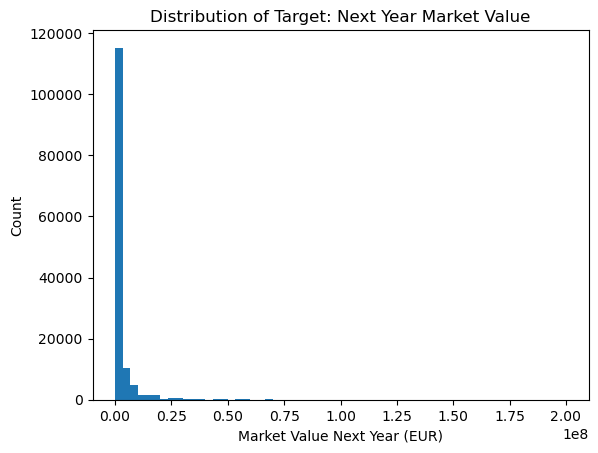

In [40]:
# Statistics

display(y.describe())

plt.figure()
plt.hist(y, bins=60)
plt.xlabel("Market Value Next Year (EUR)")
plt.ylabel("Count")
plt.title("Distribution of Target: Next Year Market Value")
plt.show()


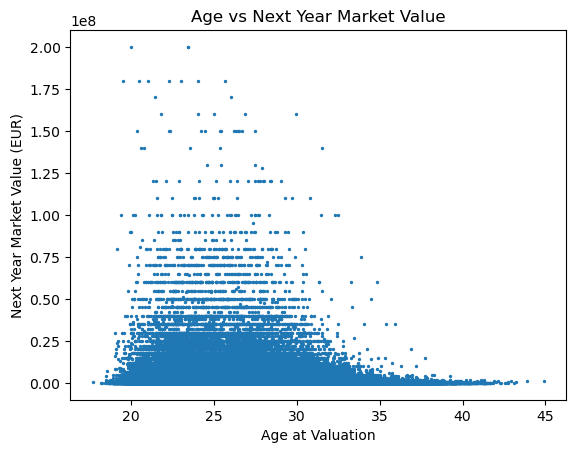

In [41]:
# age vs next-year value

plt.figure()
plt.scatter(merged_df["age_at_valuation"], merged_df["market_value_next_year"], s=2)
plt.xlabel("Age at Valuation")
plt.ylabel("Next Year Market Value (EUR)")
plt.title("Age vs Next Year Market Value")
plt.show()


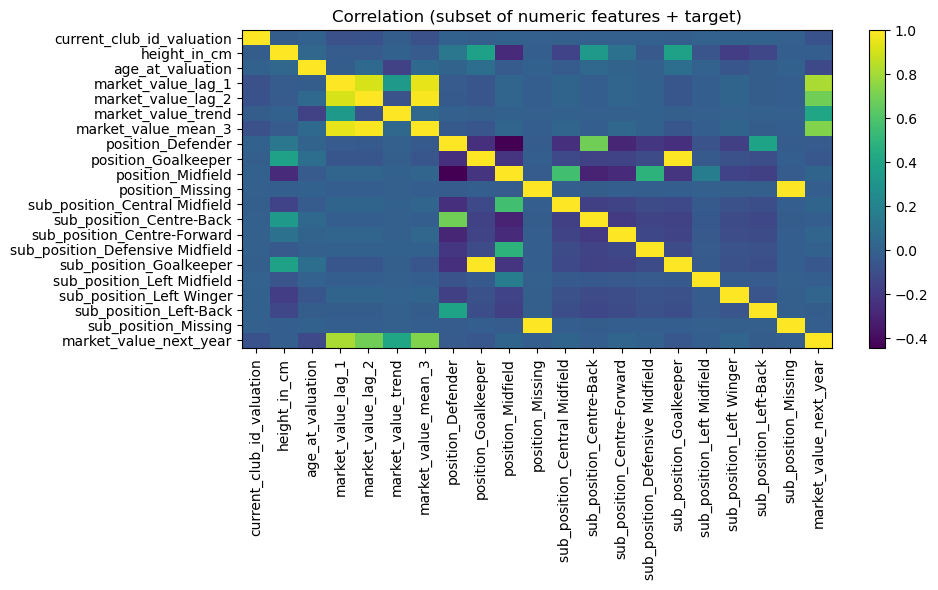

In [42]:
# Correlation heatmap (numeric subset)

num_cols = X.columns[:20]  # limit for readability
corr = pd.concat([X[num_cols], y], axis=1).corr()

plt.figure(figsize=(10,6))
plt.imshow(corr, aspect="auto")
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.index)), corr.index)
plt.title("Correlation (subset of numeric features + target)")
plt.tight_layout()
plt.show()


## 4. Data Analytics (Modeling)
This is a **supervised learning regression** problem. We compare multiple algorithms and evaluate them using MAE, RMSE, and R². We also do time-aware train/test splitting to reduce leakage risk.

In [43]:
# Train/Test split (time-aware)
# We preserve order (shuffle=False) because data is time-dependent.

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

print("Train:", X_train.shape, y_train.shape)
print("Test:", X_test.shape, y_test.shape)


Train: (110807, 40) (110807,)
Test: (27702, 40) (27702,)


We compare:
- Linear Regression (baseline)
- ElasticNet (regularized linear)
- Random Forest (non-linear)
- KNN (distance-based)

For KNN and ElasticNet we benefit from scaling, so we use pipelines.

In [44]:
# Models + evaluation

# def evaluate_model(name,model, X_tr, y_tr, X_te, y_te):
#     model.fit(X_tr, y_tr
#     )
#     pred = model.predict(X_te)
#     return {
#         "Model": name,
#         "MAE": mean_absolute_error(y_te, pred),
#         "RMSE": np.sqrt(mean_squared_error(y_te, pred)),
#         "R2": r2_score(y_te, pred)
#     }


def evaluate_model(name, model, X_tr, y_tr, X_te, y_te):
    """
    Train model, evaluate on test set, and perform cross-validation
    """
    # Train the model
    model.fit(X_tr, y_tr)
    
    # Test set predictions
    pred = model.predict(X_te)
    
    # Cross-validation on training set (5-fold)
    print(f"\n{'='*60}")
    print(f"Cross-Validation: {name}")
    print(f"{'='*60}")
    
    cv_r2 = cross_val_score(model, X_tr, y_tr, cv=5, scoring='r2', n_jobs=-1)
    cv_mae = -cross_val_score(model, X_tr, y_tr, cv=5, scoring='neg_mean_absolute_error', n_jobs=-1)
    cv_rmse = np.sqrt(-cross_val_score(model, X_tr, y_tr, cv=5, scoring='neg_mean_squared_error', n_jobs=-1))
    
    print(f"  R² scores:   {cv_r2}")
    print(f"  Mean R²:     {cv_r2.mean():.4f} (+/- {cv_r2.std():.4f})")
    print(f"  MAE scores:  {cv_mae}")
    print(f"  Mean MAE:    €{cv_mae.mean():,.2f} (+/- €{cv_mae.std():,.2f})")
    print(f"  RMSE scores: {cv_rmse}")
    print(f"  Mean RMSE:   €{cv_rmse.mean():,.2f} (+/- €{cv_rmse.std():,.2f})")
    
    return {
        "Model": name,
        "MAE": mean_absolute_error(y_te, pred),
        "RMSE": np.sqrt(mean_squared_error(y_te, pred)),
        "R2": r2_score(y_te, pred),
        "CV_R2_Mean": cv_r2.mean(),
        "CV_R2_Std": cv_r2.std(),
        "CV_MAE_Mean": cv_mae.mean(),
        "CV_RMSE_Mean": cv_rmse.mean()
    }

models = []

# Baselines (no scaling needed)
models.append(("Linear Regression", LinearRegression()))
models.append(("Random Forest", RandomForestRegressor(
    n_estimators=150,
    max_depth=18,
    random_state=42,
    n_jobs=-1
)))

# Pipelines (imputer + scaler) helps for KNN/ElasticNet
elastic_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", ElasticNet(alpha=0.1, l1_ratio=0.5, random_state=42))
])

knn_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", KNeighborsRegressor(n_neighbors=10))
])

models.append(("ElasticNet (scaled)", elastic_pipe))
models.append(("KNN (scaled)", knn_pipe))

results = []
for name, model in models:
    results.append(evaluate_model(name, model, X_train, y_train, X_test, y_test))

results_df = pd.DataFrame(results).sort_values("MAE")
results_df



Cross-Validation: Linear Regression
  R² scores:   [0.78265121 0.70144658 0.68942223 0.66767247 0.63884018]
  Mean R²:     0.6960 (+/- 0.0483)
  MAE scores:  [1472459.52643076 1345310.15788415 1322214.20901184 1479772.27622996
 1729400.69307264]
  Mean MAE:    €1,469,831.37 (+/- €144,760.71)
  RMSE scores: [3040292.68192312 3151623.12474915 3601515.04364597 4173056.26322785
 4457272.43668209]
  Mean RMSE:   €3,684,751.91 (+/- €555,285.78)

Cross-Validation: Random Forest
  R² scores:   [0.79384306 0.74593158 0.72898132 0.7052755  0.62478795]
  Mean R²:     0.7198 (+/- 0.0557)
  MAE scores:  [1171387.48698966 1133613.07073075 1099446.05988815 1264718.66071189
 1552573.80977049]
  Mean MAE:    €1,244,347.82 (+/- €163,707.15)
  RMSE scores: [2960981.93765418 2907358.56812308 3364338.34237833 3929879.19364596
 4543158.13863134]
  Mean RMSE:   €3,541,143.24 (+/- €620,432.05)

Cross-Validation: ElasticNet (scaled)
  R² scores:   [0.77811939 0.69895162 0.68676696 0.66513575 0.63861563]
  Mea

,Model,MAE,RMSE,R2,CV_R2_Mean,CV_R2_Std,CV_MAE_Mean,CV_RMSE_Mean
1,Random Forest,2.108117e+06,5.879620e+06,0.687193,0.719764,0.055656,1.244348e+06,3.541143e+06
0,Linear Regression,2.278300e+06,5.701673e+06,0.705841,0.696007,0.048272,1.469831e+06,3.684752e+06
3,KNN (scaled),2.285247e+06,6.252842e+06,0.646221,0.643032,0.038918,1.444792e+06,3.991616e+06
2,ElasticNet (scaled),2.302445e+06,5.770425e+06,0.698704,0.693518,0.047016,1.472896e+06,3.700216e+06


We use `TimeSeriesSplit` to evaluate models with time-aware cross-validation. This avoids mixing future information into training folds.

In [45]:
# TimeSeries cross-validation (on a subset for speed)

tscv = TimeSeriesSplit(n_splits=5)

# For speed, sample a subset
sample_size = min(120000, len(X_train))
X_cv = X_train.iloc[:sample_size]
y_cv = y_train.iloc[:sample_size]

# Use MAE (negative in sklearn scoring conventions)
def cv_mae(model):
    scores = cross_val_score(
        model, X_cv, y_cv,
        cv=tscv,
        scoring="neg_mean_absolute_error",
        n_jobs=-1
    )
    return -scores.mean(), scores.std()

cv_rows = []
for name, model in models:
    mean_mae, std_mae = cv_mae(model)
    cv_rows.append({"Model": name, "CV_MAE_mean": mean_mae, "CV_MAE_std": std_mae})

cv_df = pd.DataFrame(cv_rows).sort_values("CV_MAE_mean")
cv_df

,Model,CV_MAE_mean,CV_MAE_std
1,Random Forest,1.272931e+06,184340.880386
0,Linear Regression,1.481909e+06,162446.529952
2,ElasticNet (scaled),1.494259e+06,161227.808507
3,KNN (scaled),1.538484e+06,138336.576371


We inspect which features contribute most to predictions (interpretability).

market_value_lag_1                       0.689571
age_at_valuation                         0.113415
current_club_id_valuation                0.036594
height_in_cm                             0.028135
market_value_mean_3                      0.026147
market_value_trend                       0.024185
market_value_lag_2                       0.014798
domestic_competition_id_valuation_GB1    0.005909
sub_position_Centre-Forward              0.005751
domestic_competition_id_valuation_FR1    0.005747
domestic_competition_id_valuation_ES1    0.004856
sub_position_Right Winger                0.003330
sub_position_Left Winger                 0.003259
position_Midfield                        0.003169
foot_left                                0.003091
dtype: float64

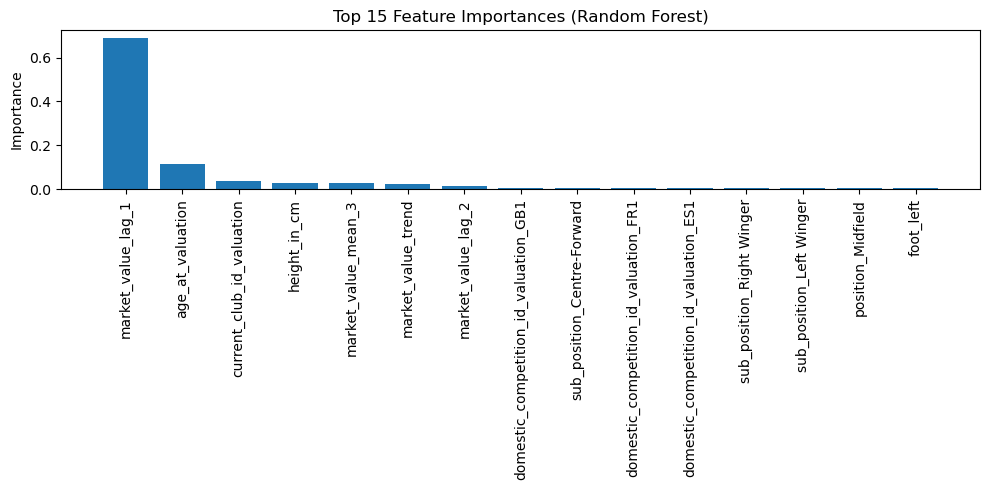

In [46]:
# Feature importance (Random Forest)

# Train Random Forest
rf = RandomForestRegressor(
    n_estimators=150,
    max_depth=18,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

# Compute importances
importances = pd.Series(
    rf.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

# Display top features as table
top_k = 15
display(importances.head(top_k))

# Plot feature importances (safe 1D float arrays)
top_feats = importances.head(top_k)

x = np.arange(len(top_feats))
y = top_feats.to_numpy(dtype=float)

plt.figure(figsize=(10, 5))
plt.bar(x, y)
plt.xticks(x, top_feats.index, rotation=90)
plt.ylabel("Importance")
plt.title(f"Top {top_k} Feature Importances (Random Forest)")
plt.tight_layout()
plt.show()


A quick diagnostic plot to visually assess model fit.

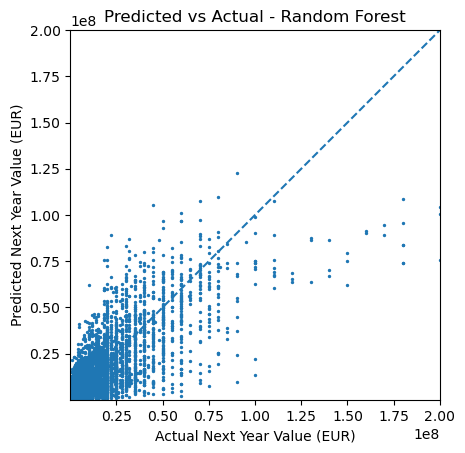

In [47]:
# Predicted vs actual

best_model_name = results_df.iloc[0]["Model"]
best_model = dict(models)[best_model_name]
best_model.fit(X_train, y_train)
pred = best_model.predict(X_test)

min_val = min(y_test.min(), pred.min())
max_val = max(y_test.max(), pred.max())

plt.figure()
plt.scatter(y_test, pred, s=2)

plt.xlim(min_val, max_val)
plt.ylim(min_val, max_val)

plt.gca().set_aspect("equal", adjustable="box")

plt.plot([min_val,max_val],[min_val,max_val],linestyle='--')

plt.xlabel("Actual Next Year Value (EUR)")
plt.ylabel("Predicted Next Year Value (EUR)")
plt.title(f"Predicted vs Actual - {best_model_name}")
plt.show()


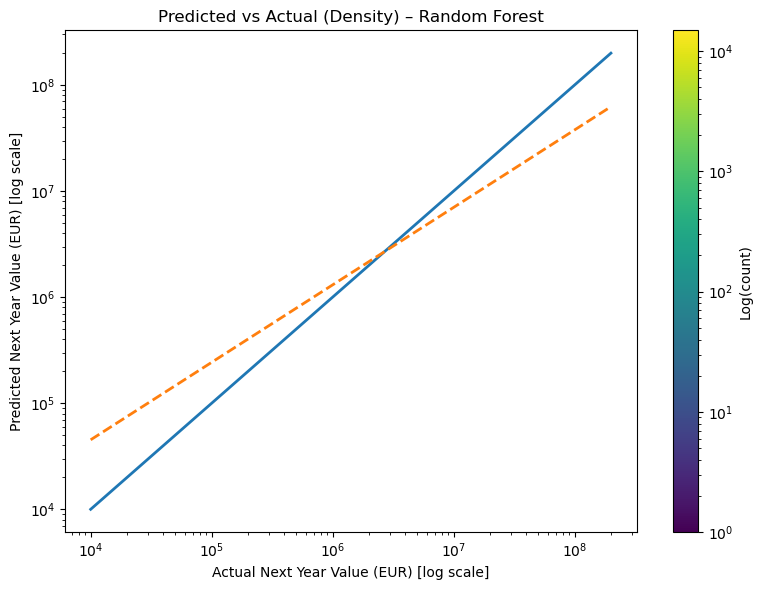

In [48]:
# Predicted vs Actual 

final_model_name = results_df.iloc[0]["Model"]
final_model = dict(models)[final_model_name]

final_model.fit(X_train, y_train)
pred = final_model.predict(X_test)

# Convert to numpy arrays and remove non-positive values for log scaling
y_true = np.asarray(y_test).astype(float)
y_pred = np.asarray(pred).astype(float)

mask = (y_true > 0) & (y_pred > 0) & np.isfinite(y_true) & np.isfinite(y_pred)
y_true = y_true[mask]
y_pred = y_pred[mask]

# 1) HEXBIN DENSITY PLOT (final when there are many points)
plt.figure(figsize=(8, 6))
hb = plt.hexbin(y_true, y_pred, gridsize=60, bins='log')  # density in log bins
plt.colorbar(hb, label="Log(count)")

# Log scales (makes long-tail readable)
plt.xscale("log")
plt.yscale("log")

# 45-degree line (perfect predictions)
min_v = min(y_true.min(), y_pred.min())
max_v = max(y_true.max(), y_pred.max())
plt.plot([min_v, max_v], [min_v, max_v], linewidth=2)

# Fit line to log10 values to show overall calibration
logx = np.log10(y_true)
logy = np.log10(y_pred)
m, b = np.polyfit(logx, logy, 1)
x_line = np.logspace(np.log10(min_v), np.log10(max_v), 200)
y_line = 10**(m*np.log10(x_line) + b)
plt.plot(x_line, y_line, linestyle="--", linewidth=2)

plt.xlabel("Actual Next Year Value (EUR) [log scale]")
plt.ylabel("Predicted Next Year Value (EUR) [log scale]")
plt.title(f"Predicted vs Actual (Density) – {final_model_name}")
plt.tight_layout()
plt.show()
